In [ ]:
%pip install cvxopt


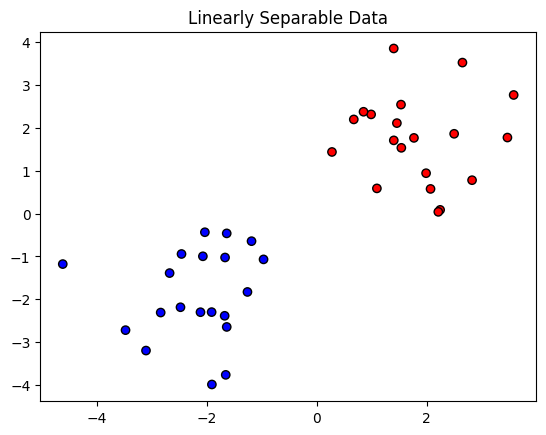

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

np.random.seed(42)
X1 = np.random.randn(20, 2) + np.array([2, 2])
X2 = np.random.randn(20, 2) + np.array([-2, -2])
X = np.vstack((X1, X2))
y = np.hstack((np.ones(20), -np.ones(20)))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title("Linearly Separable Data")
plt.show()

In [ ]:
def train_svm(X, y):
    n_samples, n_features = X.shape
    K = (y[:, None] * X) @ (y[:, None] * X).T
    P = matrix(K)
    q = matrix(-np.ones((n_samples, 1)))
    G = matrix(-np.eye(n_samples))
    h = matrix(np.zeros(n_samples))
    A = matrix(y.reshape(1, -1))
    b = matrix(np.zeros(1))
    dictionary = {"P": P, "q": q, "A": A, "b": b, "G": G, "h": h}
    for key, val in dictionary.items():
      print(key, val.size)
    solvers.options['show_progress'] = True
    solution = solvers.qp(P, q, G, h, A, b)

    alphas = np.ravel(solution['x'])

    is_sv = alphas > 1e-5
    is_not_sv = alphas <=1e-5
    sv_idx = np.where(is_sv)[0]
    non_sv_idx = np.where(is_not_sv)[0]

    w = ((alphas * y)[:, None] * X).sum(axis=0)

    b = y[sv_idx[0]] - np.dot(X[sv_idx[0]], w)

    return w, b, X[sv_idx] , X[non_sv_idx]

w, b, support_vectors, non_support_vectors = train_svm(X, y)
print(f"Weights: {w}")
print(f"Bias: {b}")

P (40, 40)
q (40, 1)
A (1, 40)
b (1, 1)
G (40, 40)
h (40, 1)
     pcost       dcost       gap    pres   dres
 0: -4.3151e+00 -7.0959e+00  1e+02  1e+01  2e+00
 1: -3.0057e+00 -1.2095e+00  1e+01  1e+00  2e-01
 2: -9.7240e-02 -5.2743e-01  4e-01  2e-04  3e-05
 3: -2.5139e-01 -3.3206e-01  8e-02  3e-05  4e-06
 4: -3.1261e-01 -3.2181e-01  9e-03  1e-06  2e-07
 5: -3.2073e-01 -3.2083e-01  1e-04  1e-08  2e-09
 6: -3.2082e-01 -3.2082e-01  1e-06  1e-10  2e-11
 7: -3.2082e-01 -3.2082e-01  1e-08  1e-12  2e-13
Optimal solution found.
Weights: [0.5775472  0.55504203]
Bias: 0.04313621944571144


In [ ]:
print(support_vectors)

[[ 0.27508217  1.43771247]
 [ 1.09197592  0.5876963 ]
 [-1.18747418 -0.64375997]]


In [ ]:
print(non_support_vectors)

[[ 2.49671415  1.8617357 ]
 [ 2.64768854  3.52302986]
 [ 1.76584663  1.76586304]
 [ 3.57921282  2.76743473]
 [ 1.53052561  2.54256004]
 [ 1.53658231  1.53427025]
 [ 2.24196227  0.08671976]
 [ 0.98716888  2.31424733]
 [ 3.46564877  1.7742237 ]
 [ 2.0675282   0.57525181]
 [ 1.45561728  2.11092259]
 [ 0.84900642  2.37569802]
 [ 1.39936131  1.70830625]
 [ 1.39829339  3.85227818]
 [ 1.98650278  0.94228907]
 [ 2.82254491  0.77915635]
 [ 2.2088636   0.04032988]
 [ 0.67181395  2.19686124]
 [-1.26153342 -1.82863172]
 [-2.11564828 -2.3011037 ]
 [-3.47852199 -2.71984421]
 [-2.46063877 -0.94287777]
 [-1.65638171 -3.76304016]
 [-1.67591603 -2.38508228]
 [-2.676922   -1.38832371]
 [-0.96900048 -1.06871988]
 [-2.83921752 -2.30921238]
 [-1.66873657 -1.02445487]
 [-2.47917424 -2.18565898]
 [-3.10633497 -3.19620662]
 [-2.07201012 -0.9964671 ]
 [-1.63836397 -2.64511975]
 [-1.63860439 -0.46196343]
 [-2.03582604 -0.43535634]
 [-4.6197451  -1.1780975 ]
 [-1.91295293 -2.29900735]
 [-1.90823922 -3.98756891]]


In [ ]:
print(f"No of support vectors: {support_vectors.shape[0]}")
print(f"No of non-support vectors: {non_support_vectors.shape[0]}")

No of support vectors: 3
No of non-support vectors: 37


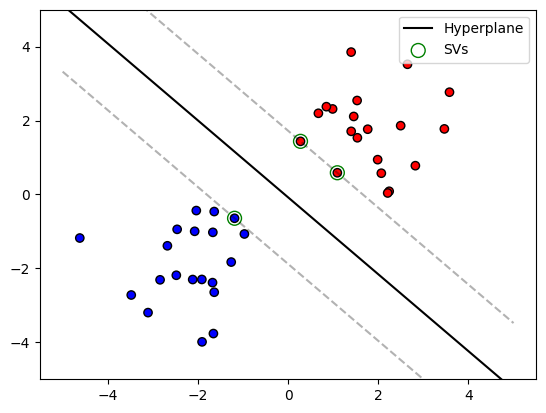

In [ ]:
def plot_svm(X, y, w, b, sv):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')

    x_points = np.linspace(-5, 5, 100)
    y_points = -(w[0] * x_points + b) / w[1]

    plt.plot(x_points, y_points, 'k-', label="Hyperplane")
    plt.plot(x_points, y_points + 1/w[1], 'k--', alpha=0.3)
    plt.plot(x_points, y_points - 1/w[1], 'k--', alpha=0.3)

    plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='g', label="SVs")

    plt.ylim(-5, 5)
    plt.legend()
    plt.show()

plot_svm(X, y, w, b, support_vectors)